In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
def create_ages(mu=50, sigma=13,num_samples=100,seed=42):
    np.random.seed(seed)

    sample_ages=np.random.normal(loc=mu,scale=sigma,size=num_samples)
    sample_ages=np.round(sample_ages,decimals=0)

    return sample_ages

In [6]:
sample=create_ages()

In [7]:
sample

array([56., 48., 58., 70., 47., 47., 71., 60., 44., 57., 44., 44., 53.,
       25., 28., 43., 37., 54., 38., 32., 69., 47., 51., 31., 43., 51.,
       35., 55., 42., 46., 42., 74., 50., 36., 61., 34., 53., 25., 33.,
       53., 60., 52., 48., 46., 31., 41., 44., 64., 54., 27., 54., 45.,
       41., 58., 63., 62., 39., 46., 54., 63., 44., 48., 36., 34., 61.,
       68., 49., 63., 55., 42., 55., 70., 50., 70., 16., 61., 51., 46.,
       51., 24., 47., 55., 69., 43., 39., 43., 62., 54., 43., 57., 51.,
       63., 41., 46., 45., 31., 54., 53., 50., 47.])

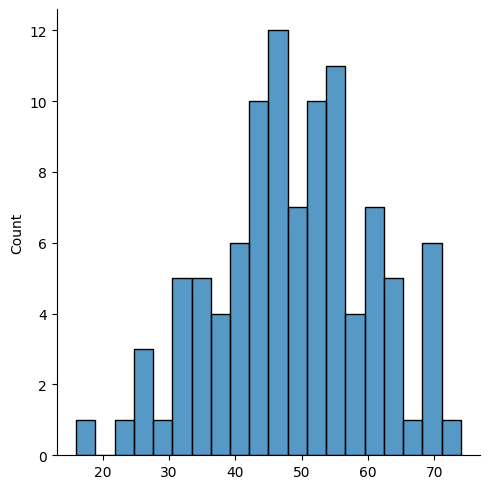

In [9]:
sns.displot(sample,bins=20)

<Axes: >

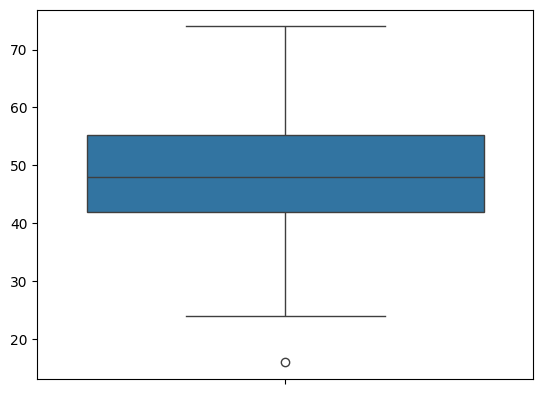

In [10]:
sns.boxplot(sample)

In [11]:
ser=pd.Series(sample)

In [13]:
ser.describe()

count    100.00000
mean      48.66000
std       11.82039
min       16.00000
25%       42.00000
50%       48.00000
75%       55.25000
max       74.00000
dtype: float64

In [15]:
IQR=55.25-42.0
Lower_limit=42.0-1.5*(IQR)

In [16]:
Lower_limit

22.125

In [17]:
ser>Lower_limit

0     True
1     True
2     True
3     True
4     True
      ... 
95    True
96    True
97    True
98    True
99    True
Length: 100, dtype: bool

In [19]:
np.percentile(sample,[75])

array([55.25])

In [22]:
df=pd.read_csv('AmesHousing.csv')

In [23]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [25]:
df.corr()['SalePrice']

ValueError: could not convert string to float: 'RL'

<Axes: xlabel='Overall Qual', ylabel='SalePrice'>

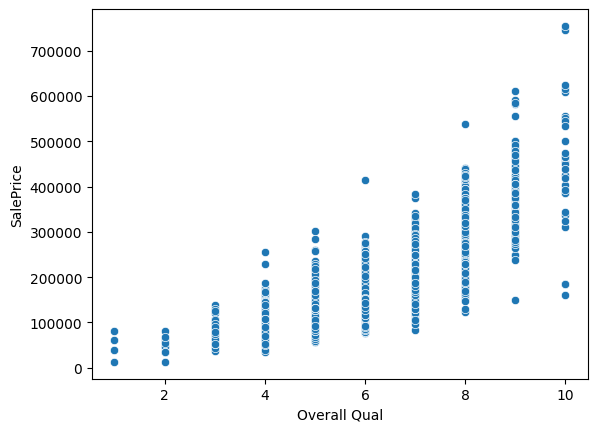

In [28]:
sns.scatterplot(x='Overall Qual',y='SalePrice',data=df)

<Axes: xlabel='Gr Liv Area', ylabel='SalePrice'>

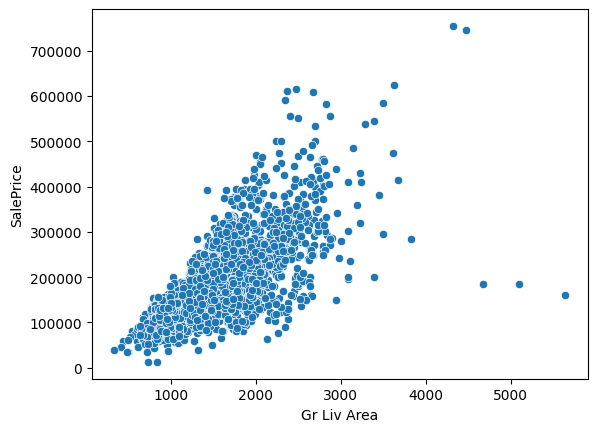

In [29]:
sns.scatterplot(x='Gr Liv Area',y='SalePrice',data=df)

In [32]:
df.loc[(df['Overall Qual']>8) & (df['SalePrice']<200000)]

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1182,1183,533350090,60,RL,NaN,24572,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2008,WD,Family,150000
1498,1499,908154235,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000
2180,2181,908154195,20,RL,128.0,39290,Pave,NaN,IR1,Bnk,...,0,NaN,NaN,Elev,17000,10,2007,New,Partial,183850
2181,2182,908154205,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750


In [36]:
drop_index=df[(df['Gr Liv Area']>4000) & (df['SalePrice']<400000)].index

In [37]:
df=df.drop(drop_index,axis=0)

<Axes: xlabel='Gr Liv Area', ylabel='SalePrice'>

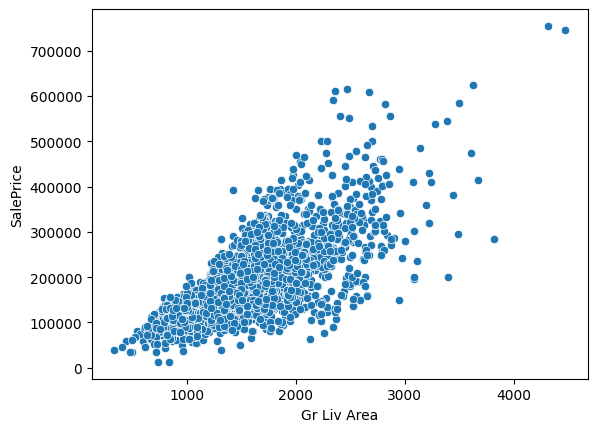

In [38]:
sns.scatterplot(x='Gr Liv Area',y='SalePrice',data=df)

In [39]:
df.to_csv('AMESFINAL')